# 07 — XGBoost Nowcasting

**Thesis:** *Nowcasting and Indicator Selection in a Data-Rich Environment: An Application to German GDP Growth*

Non-linear benchmark on the same first-release target, publication-lag mask, AR fill and 2011Q1–2025Q4 M3 grid as the DFM.

**XGB-Full** uses the coverage-eligible panel (~580 series per origin), not the Part I selection matrices. Hyperparameters are tuned once on the pre-2011 window (on the vote-set design plus GDP lags L1–L2) and then frozen. Every four origins the smallest base-series set carrying 90% of mean absolute SHAP mass is retained (floor 20); GDP lags are never pruned.

| Window | RMSFE |
|---|---:|
| Full sample | 1.386 |
| pre-COVID | 0.352 |
| COVID | 3.704 |
| post-COVID (seed 42) | 0.248 |

The post-COVID figure is the best of five seeds (0.248–0.618). It does not significantly beat the rolling AR(1) it trails (*p* = 0.452). Full-sample RMSFE is worse than DFM-EN (1.386 against 0.784); that gap is not certified at this sample size. SHAP mass tilts towards hard activity (72.3–76.8%), with rank correlation 0.375 against the elastic net.


## §0  Setup

In [1]:
from __future__ import annotations
%matplotlib inline
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio

pio.renderers.default = "plotly_mimetype"

# --- Portable repository setup ---
_repo = next(
    (base for base in (Path.cwd(), *Path.cwd().parents)
     if (base / "src" / "german_gdp_nowcasting").is_dir()),
    None,
)
if _repo is None:
    raise RuntimeError("Could not locate src/german_gdp_nowcasting.")
_src = _repo / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from german_gdp_nowcasting.config import paths as _tp
from german_gdp_nowcasting.models.xgboost import xgb_utils as xu
from german_gdp_nowcasting.visualization import xgb_plots as xp
from german_gdp_nowcasting.selection.core_utils import (
    load_monthly_panel,
    load_pub_lag_map,
    load_trafo_map,
    build_coverage_mask,
    make_monthly_forecast_origins,
)
from german_gdp_nowcasting.models.dfm.nowcast_utils import (
    compute_rmsfe,
    compute_nsr,
    diebold_mariano_test,
    build_rmsfe_table,
    align_forecast_errors,
    subset_eval_window,
)

xp.setup_style()
HEADLINE_MIQ = xu.HEADLINE_MIQ  # M3 end-of-quarter, matching notebook 06
EVAL_START = "2011Q1"
EVAL_END = "2025Q4"
TRAIN_START = "1991Q1"
TUNE_END = "2010Q4"   # pre-evaluation tuning window
GDP_LAGS = (1, 2)      # quarterly AR lags appended to every design matrix
# Expensive loops and tuning are opt-in.
FORCE_RERUN_LOOPS = False
FORCE_RETUNE = False
OUT_DIR = _tp.OUT_NOWCASTING
FIG_DIR = _tp.NOWCAST_FIGURES_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Repo    : {_tp.REPO_ROOT}')
print(f'Dataset : {_tp.DATASET_XLSX}')
print(f'Data    : {_tp.DATA}')
print(f'Outputs : {_tp.OUTPUTS}')
print(f"Eval window: {EVAL_START} – {EVAL_END}")
print(f"GDP AR lags: {GDP_LAGS}")


Repo    : /Users/niki/M.Sc Thesis/german-gdp-nowcasting
Dataset : /Users/niki/M.Sc Thesis/Dataset/ifoCAST_DATA.xlsx
Data    : /Users/niki/M.Sc Thesis/Project_files/data
Outputs : /Users/niki/M.Sc Thesis/Project_files/outputs
Eval window: 2011Q1 – 2025Q4
GDP AR lags: (1, 2)


## §1  Load inputs

Same inputs as `06_dfm_nowcasting.ipynb`: transformed monthly panel, publication-lag map, GDP first-release target, and the transformation map produced upstream.


In [2]:
X_monthly = load_monthly_panel(_tp.PANEL_TRANSFORMED_CSV)
pub_lag_map = load_pub_lag_map(_tp.PUB_LAG_CSV)
trafo_map = load_trafo_map(_tp.DATA_DICT_ENRICHED_CSV)
_y_raw = pd.read_csv(_tp.GDP_TARGET_CSV)
_y_raw["quarter"] = pd.PeriodIndex(_y_raw["quarter"], freq="Q")
y_quarterly = _y_raw.set_index("quarter").iloc[:, 0]
y_quarterly.name = "gdp"
forecast_origins = make_monthly_forecast_origins("2011-01", "2025-12")
quarterly_origins = pd.period_range(EVAL_START, EVAL_END, freq="Q")
print(f"X_monthly         : {X_monthly.shape}  ({X_monthly.index.min().date()} → {X_monthly.index.max().date()})")
print(f"y_quarterly       : {y_quarterly.shape}  ({y_quarterly.index.min()} → {y_quarterly.index.max()})")
print(f"pub_lag_map       : {pub_lag_map.shape}")
print(f"quarterly origins : {len(quarterly_origins)} quarters")


X_monthly         : (420, 585)  (1991-01-01 → 2025-12-01)
y_quarterly       : (139,)  (1991Q2 → 2025Q4)
pub_lag_map       : (585,)
quarterly origins : 60 quarters


## §2  Real-time information set

Same two-stage ragged edge as the DFM, then the raw-level quarterly bridge and lags L0–L2 of each indicator. GDP lags L1–L2 are appended so the trees can match an AR(1) when the monthly panel adds nothing. Headline evaluation is M3 only (60 origins).


## §3  Hyperparameter tuning

Once, on 1991Q1–2010Q4, `RandomizedSearchCV` with `TimeSeriesSplit(5)`, 40 draws. Search space as in the thesis appendix. Tuning uses the vote-set design plus GDP lags (~95 features), then those parameters are reused on XGB-Full. Cached in `xgb_best_params.json`.


In [3]:
params_cache = xu.load_params(_tp.XGB_BEST_PARAMS_JSON)
if params_cache is not None and not FORCE_RETUNE:
    BEST_PARAMS = params_cache["params"]
    print("Loaded cached XGB hyperparameters:")
    for k, v in BEST_PARAMS.items():
        print(f"  {k:>17s}: {v}")
    print(f"  cached CV RMSE  : {params_cache.get('cv_rmse', float('nan')):.4f}")
else:
    # Only core selection matrix is needed for tuning (see §3 markdown for rationale).
    tune_sel = pd.read_csv(_tp.CORE_MATRIX_CSV, index_col="forecast_origin").astype(int)
    tune_origin = pd.Period("2010-12", freq="M")
    tune_q = tune_origin.asfreq("Q")
    m3_key = str(xu.quarter_to_m3_period(tune_q))
    if m3_key not in tune_sel.index:
        earlier = tune_sel.index[tune_sel.index <= m3_key]
        m3_key = earlier[-1] if len(earlier) > 0 else tune_sel.index[0]
    tune_cols = tune_sel.columns[tune_sel.loc[m3_key].astype(bool)].tolist()
    print(f"Tuning origin {tune_origin} (core row {m3_key}, N={len(tune_cols)} indicators + GDP lags {GDP_LAGS})")
    X_tr, y_tr, _ = xu.build_xgb_design_matrix(
        X_monthly=X_monthly, y_quarterly=y_quarterly, origin=tune_origin,
        selected_cols=tune_cols, pub_lag_map=pub_lag_map,
        lags=xu.DEFAULT_LAGS, train_start=TRAIN_START, trafo_map=trafo_map,
        fill_method="ar_bic", gdp_lags=GDP_LAGS,
    )
    print(f"Tuning design matrix: {X_tr.shape}")
    hp = xu.tune_xgb(X_tr, y_tr, n_iter=40, cv_splits=5)
    BEST_PARAMS = hp.params
    xu.save_params(_tp.XGB_BEST_PARAMS_JSON, hp)
    print(f"Best CV RMSE = {hp.cv_rmse:.4f}")
    print("Best params:")
    for k, v in BEST_PARAMS.items():
        print(f"  {k:>17s}: {v}")


Loaded cached XGB hyperparameters:
          subsample: 0.6
         reg_lambda: 1.0
          reg_alpha: 0.0
       n_estimators: 500
   min_child_weight: 1
          max_depth: 6
      learning_rate: 0.025
   colsample_bytree: 0.7
  cached CV RMSE  : 0.5994


## §4  Expanding-window loop

XGB-Full uses the coverage-eligible panel. Every four quarters, SHAP pruning keeps the smallest base-series set carrying 90% of mean absolute SHAP mass (floor 20). GDP lags L1–L2 are never dropped.

| Component | Detail |
|---|---|
| Pre-SHAP | ~580 series × lags 0–2 |
| Post-SHAP | ~170–200 base series × 3 lags, plus two GDP lags |

The design remains high-dimensional relative to the training sample (about 80 quarters at the first origin). Shrinkage comes mainly from the tree regularisation chosen in §3.

If `nowcast_results_xgb_full.csv` exists, set `FORCE_RERUN_LOOPS = True` to refit.


In [4]:
coverage_mask = build_coverage_mask(X_monthly, forecast_origins, min_coverage=0.30)
xgb_results: dict[str, pd.DataFrame] = {}
xgb_shap_logs: dict[str, pd.DataFrame] = {}
FULL_KEY = "full"
csv_full = _tp.xgb_results_csv(FULL_KEY)
shap_csv = _tp.XGB_SHAP_IMPORTANCE_CSV
if xu.needs_run(csv_full, force=FORCE_RERUN_LOOPS):
    print('Running XGB-Full (SHAP pruning every four quarters)')
    df_full, shap_log = xu.run_xgb_nowcast_loop(
        selection_matrix=None,
        X_monthly=X_monthly,
        y_quarterly=y_quarterly,
        params=BEST_PARAMS,
        quarterly_origins=quarterly_origins,
        pub_lag_map=pub_lag_map,
        lags=xu.DEFAULT_LAGS,
        train_start=TRAIN_START,
        trafo_map=trafo_map,
        fill_method="ar_bic",
        gdp_lags=GDP_LAGS,
        coverage_mask=coverage_mask,
        shap_pruning=True,
        shap_refit_every=4,
        shap_keep_frac=0.90,
        shap_min_features=20,
        shap_log_every=1,
        verbose=True,
    )
    df_full.to_csv(csv_full)
    if not shap_log.empty:
        shap_log.to_csv(shap_csv)
else:
    print(f'Loaded XGB-Full from {csv_full.name}')
    df_full = pd.read_csv(csv_full, index_col="quarter")
    shap_log = (
        pd.read_csv(shap_csv).set_index(["quarter", "feature"])
        if shap_csv.exists() else pd.DataFrame()
    )
xgb_results["XGB-Full"] = df_full
xgb_shap_logs["XGB-Full"] = shap_log


Loaded XGB-Full from nowcast_results_xgb_full.csv


In [5]:
# Save with empirical 90% prediction interval.
df_full = xu.compute_xgb_intervals(xgb_results["XGB-Full"], alpha=0.10, min_history=8)
xgb_results["XGB-Full"] = df_full
df_full.to_csv(_tp.xgb_results_csv("full"))
summary = pd.DataFrame({
    "XGB-Full": {
        "n_obs":         int(df_full["nowcast"].notna().sum()),
        "RMSFE":         compute_rmsfe(df_full, EVAL_START, EVAL_END, month_in_quarter=HEADLINE_MIQ),
        "mean_features": float(df_full["n_features"].mean()) if "n_features" in df_full else float("nan"),
    }
}).T
print(summary.round(4).to_string())
_xgb = float(summary.loc['XGB-Full', 'RMSFE'])
if abs(_xgb - 1.386) > 0.02:
    print(f'WARNING: this CSV has RMSFE {_xgb:.3f}. Thesis XGB-Full (seed 42) is 1.386. Cite the title-cell table.')


          n_obs   RMSFE  mean_features
XGB-Full   60.0  1.3858          562.6


## §5  SHAP analysis (XGB-Full)

Mean |SHAP| per (base) feature averaged over the SHAP-refit quarters; bar chart with cross-time dispersion as error bars.


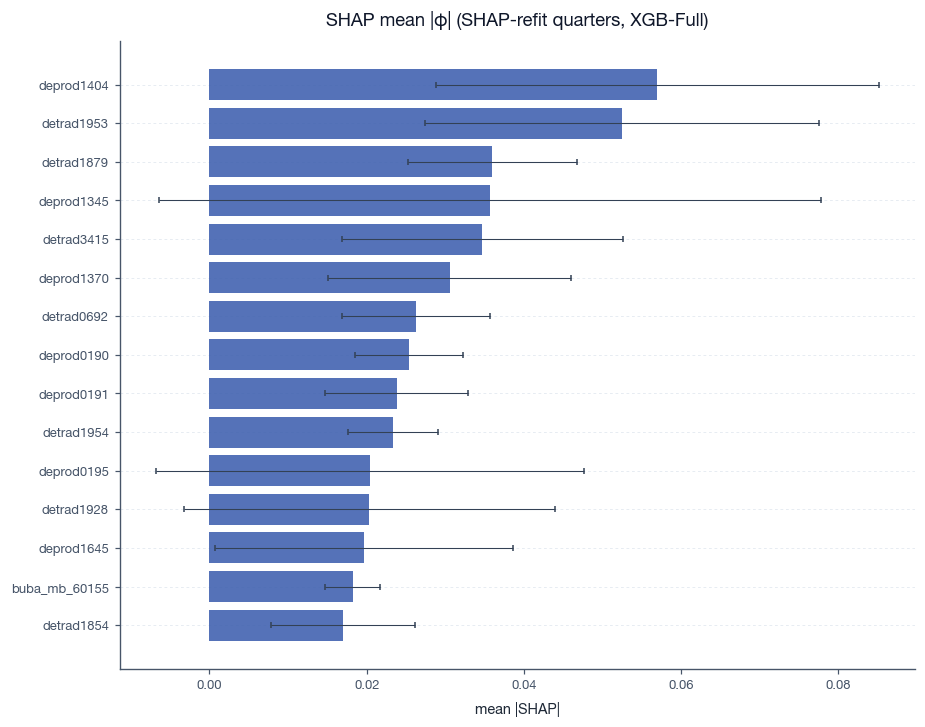

Top 15 variables by mean |SHAP| (full names from data dict):

  deprod1404
    Germany, Industrial Production, Total, Calendar Adjusted (X13 JDemetra+), Constant Prices, SA (X13 JDemetra+), Index

  detrad1953
    Germany, Production Sales, Turnover, Durable Goods, Total, Calendar Adjusted (X13 JDemetra+), Constant Prices, SA (X13 JDemetra+), Index

  detrad1879
    Germany, Production Sales, Turnover, Intermediate Goods, Domestic Markets, Calendar Adjusted (X13 JDemetra+), Constant Prices, SA (X13 JDemetra+), Index

  deprod1345
    Germany, Industrial Production, By Goods, Intermediate Goods, Calendar Adjusted (X13 JDemetra+), Constant Prices, SA (X13 JDemetra+), Index

  detrad3415
    Germany, Production Sales, Turnover, Manufacturing, Domestic Markets, Calendar Adjusted (X13 JDemetra+), Constant Prices, SA (X13 JDemetra+), Index

  deprod1370
    Germany, Industrial Production, Total, Excluding Construction, Calendar Adjusted (X13 JDemetra+), Constant Prices, SA (X13 JDemetra+), I

In [6]:
shap_log = xgb_shap_logs.get("XGB-Full", pd.DataFrame())
TOP_SHAP = 15
fig = xp.fig_shap_bar(shap_log, top_n=TOP_SHAP, aggregate_lags=True)
xp.save_fig(fig, FIG_DIR / "xgb_05_shap_bar.png"); plt.show()
# Same ranking as ``fig_shap_bar`` (aggregate lags → base series id).
if shap_log.empty:
    print("No SHAP log — no top variables to list.")
else:
    shap_df = shap_log.reset_index()
    shap_df["feature_base"] = shap_df["feature"].map(
        lambda c: c.rsplit("__L", 1)[0] if "__L" in c else c
    )
    agg = shap_df.groupby(["quarter", "feature_base"], as_index=False)["mean_abs_shap"].sum()
    stats = (
        agg.groupby("feature_base")["mean_abs_shap"]
        .agg(["mean", "std"])
        .sort_values("mean", ascending=False)
        .head(TOP_SHAP)
    )
    name_map = (
        pd.read_csv(_tp.DATA_DICT_ENRICHED_CSV, usecols=["id", "name"])
        .drop_duplicates(subset="id")
        .set_index("id")["name"]
    )
    print(f"Top {TOP_SHAP} variables by mean |SHAP| (full names from data dict):\n")
    for sid in stats.index:
        full = name_map.get(sid, "(no matching id in data_dict_enriched.csv)")
        print(f"  {sid}\n    {full}\n")


In [7]:
# Plotly — SHAP mass by indicator category (hover / zoom)
if shap_log.empty:
    print("No SHAP log — run XGB-Full in §4 first.")
else:
    _dd = pd.read_csv(_tp.DATA_DICT_ENRICHED_CSV)
    cat_map = _dd.set_index("id")["category"]
    xp.fig_xgb_shap_category_interactive(shap_log, cat_map, show=True)

## §6  Evaluation

Loads the DFM and AR results and compares them with XGB-Full. Diebold–Mariano *p*-values versus the expanding AR(1) use squared-error loss and the HLN correction. NSR is RMSFE divided by the standard deviation of the target.


In [8]:
def _read_results(path: Path) -> pd.DataFrame:
    """Load nowcast CSV; keep monthly_origin / month_in_quarter for M3 filtering."""
    return pd.read_csv(path)


In [9]:
DFM_FILES = {
    "AR1":                _tp.AR1_RESULTS_CSV,
    "RW":                 _tp.RW_RESULTS_CSV,
    "DFM-ifoCAST":        _tp.IFO_RESULTS_CSV,
    "DFM-EN":             _tp.actpn_results_csv("en_only"),
    "DFM-BlockBalanced":  _tp.BLOCKBALANCED_RESULTS_CSV,
    "DFM-SV-k2":          _tp.ACTPN_SV_RESULTS_K2_CSV,
    "combo_equal":        _tp.COMBO_EQUAL_PATH_CSV,
}
all_results: dict[str, pd.DataFrame] = {}
for name, p in DFM_FILES.items():
    if Path(p).exists():
        all_results[name] = _read_results(Path(p))
# XGB-Full from §4–§5 (or reload from disk if kernel was restarted)
if "xgb_results" not in globals() or "XGB-Full" not in xgb_results:
    p_full = _tp.xgb_results_csv("full")
    if Path(p_full).exists():
        xgb_results = {"XGB-Full": pd.read_csv(p_full, index_col="quarter")}
all_results.update(xgb_results)
print(f"Loaded {len(all_results)} models: {list(all_results.keys())}")


Loaded 8 models: ['AR1', 'RW', 'DFM-ifoCAST', 'DFM-EN', 'DFM-BlockBalanced', 'DFM-SV-k2', 'combo_equal', 'XGB-Full']


In [10]:
rmsfe_table = build_rmsfe_table(
    all_results,
    reference_key="DFM-EN",
    eval_start=EVAL_START,
    eval_end=EVAL_END,
    y_quarterly=y_quarterly,
    month_in_quarter=HEADLINE_MIQ,
)
ar1_df = all_results.get("AR1", pd.DataFrame())
dm_rows = []
for name, df in all_results.items():
    if name == "AR1":
        continue
    e_a, e_b = align_forecast_errors(df, ar1_df, month_in_quarter=HEADLINE_MIQ)
    if len(e_a) < 8:
        dm_p = np.nan
    else:
        dm_p = diebold_mariano_test(e_a, e_b, h=1, loss="se")["p_value"]
    dm_rows.append({"model": name, "DM_vs_AR1_p": dm_p})
dm_df = pd.DataFrame(dm_rows).set_index("model")
rmsfe_table = rmsfe_table.join(dm_df, how="left")
if "AR1" in rmsfe_table.index:
    ar1_rmsfe = rmsfe_table.at["AR1", "RMSFE"]
    rmsfe_table["vs_AR1"] = rmsfe_table["RMSFE"] / ar1_rmsfe
rmsfe_table = rmsfe_table.sort_values("RMSFE")
rmsfe_table.to_csv(_tp.RMSFE_TABLE_XGB_CSV)
display(rmsfe_table.round(4))


,RMSFE,RMSFE_relative,NSR,DM_vs_AR1_p,vs_AR1
model,,,,,
combo_equal,0.6769,0.8631,0.3697,0.1792,0.2814
DFM-SV-k2,0.7808,0.9957,0.4265,0.1831,0.3245
DFM-EN,0.7842,1.0000,0.4283,0.1834,0.3260
DFM-BlockBalanced,0.8423,1.0740,0.4600,0.1976,0.3501
DFM-ifoCAST,0.9497,1.2110,0.5187,0.1930,0.3948
XGB-Full,1.3858,1.7671,0.7569,0.2047,0.5760
AR1,2.4058,3.0677,1.3139,NaN,1.0000
RW,2.9219,3.7259,1.5959,0.2570,1.2145


## §7  Regime splits

| Period | Window | *N* |
|---|---|---:|
| Pre-COVID | 2011Q1–2019Q4 | 36 |
| COVID | 2020Q1–2021Q4 | 8 |
| Post-COVID | 2022Q1–2025Q4 | 16 |


In [11]:
REGIMES = {
    "pre-COVID": ("2011Q1", "2019Q4"),
    "COVID": ("2020Q1", "2021Q4"),
    "post-COVID": ("2022Q1", "2025Q4"),
}
split_rows = []
for name, df in all_results.items():
    row = {"model": name}
    for reg, (a, b) in REGIMES.items():
        row[f"RMSFE_{reg}"] = compute_rmsfe(
            df, a, b, month_in_quarter=HEADLINE_MIQ,
        )
        sub = subset_eval_window(
            df, eval_start=a, eval_end=b, month_in_quarter=HEADLINE_MIQ,
        )
        errs = sub["error"].dropna()
        row[f"MAE_{reg}"] = float(errs.abs().mean()) if len(errs) else np.nan
    split_rows.append(row)
split_table = pd.DataFrame(split_rows).set_index("model").round(4)
split_table


,RMSFE_pre-COVID,MAE_pre-COVID,RMSFE_COVID,MAE_COVID,RMSFE_post-COVID,MAE_post-COVID
model,,,,,,
AR1,0.3772,0.2822,6.5251,4.3101,0.3088,0.2678
RW,0.5078,0.3975,7.9109,5.6018,0.3808,0.3204
DFM-ifoCAST,0.2870,0.2297,2.4474,2.2105,0.4491,0.3729
DFM-EN,0.3379,0.2654,1.9212,1.6358,0.4515,0.3664
DFM-BlockBalanced,0.3638,0.2835,2.1296,1.8196,0.3082,0.2400
DFM-SV-k2,0.3371,0.2643,1.9126,1.6241,0.4492,0.3650
combo_equal,0.3118,0.2361,1.6465,1.4315,0.3792,0.3131
XGB-Full,0.3521,0.2637,3.7043,2.8658,0.2484,0.2001


### Files written

- `nowcast_results_xgb_full.csv` — M3 nowcasts with empirical 90% intervals (quantiles of past errors, minimum history of eight).
- `xgb_shap_importance.csv` — mean \|SHAP\| by quarter and feature; lagged features are summed to the series for Part I.
- `xgb_best_params.json` — frozen hyperparameters from §3.

XGB-Full is a diagnostic, not a headline nowcast: post-COVID accuracy depends on the training seed, and the model is the most compressed non-factor forecast in the Mincer–Zarnowitz comparison (β̂ = 2.064). Non-linearity is not the binding constraint on this sample; the break and the sixteen post-COVID quarters are.
